In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import torch

In [26]:
import plotly.express as px
import pandas as pd
### plot point cloud on cylindrical coordinates using plotly
def plot_point_cloud(results, xy_range):
    df = pd.DataFrame(results)
    fig = px.scatter_3d(df, x='x', y='y', z='z', color='E', size='size', size_max=5)
    fig.update_traces(marker=dict(line=dict(width=0)))
    fig.update_layout(
        width=1000,
        height=800,
        scene=dict(
            xaxis=dict(range=[-xy_range, xy_range]),
            yaxis=dict(range=[-xy_range, xy_range]),
        )
    )
    fig.show()

## Dataset

In [27]:
from dataset import SimplePflowDataset

config = 'simple_pflow.yaml'
dataset = SimplePflowDataset(config, batch_size=10)

In [28]:
for batch in dataset:
    X, y = batch
    print(X.keys())
    print(y.keys())
    break

dict_keys(['hit_x', 'hit_y', 'hit_z', 'hit_e'])
dict_keys(['part_e', 'part_x', 'part_y', 'incidence_matrix'])


In [29]:
X['hit_x'].shape

torch.Size([10, 1098])

In [30]:
from utils import transform

ev = 0

is_nan = torch.isnan(X['hit_x'][ev])
plot_dict = {k: transform(v[ev][~is_nan], k, dataset.xform_cfg, inverse=True) for k, v in X.items()}
plot_dict['x'] = plot_dict.pop('hit_x')
plot_dict['y'] = plot_dict.pop('hit_y')
plot_dict['z'] = plot_dict.pop('hit_z')
plot_dict['E'] = plot_dict.pop('hit_e')
plot_dict['size'] = (plot_dict['E'] + 1).log()

plot_point_cloud(plot_dict, xy_range=dataset.calo_cfg['width'])

## Feature distributions

In [31]:
inputs  = {'hit_e': [], 'hit_x': [], 'hit_y': [], 'hit_z': []}
targets = {'part_e': [], 'part_x': [], 'part_y': [], 'incidence_matrix': []}

num_batches = 10
for i, batch in enumerate(dataset):
    X, y = batch
    for feat in inputs:
        x = X[feat].flatten()
        x = x[~torch.isnan(x)]
        inputs[feat].append(x.cpu())
    for feat in targets:
        x = y[feat].flatten()
        x = x[~torch.isnan(x)]
        targets[feat].append(x.cpu())
    if i >= num_batches:
        break

inputs = {k: torch.cat(v) for k, v in inputs.items()}
targets = {k: torch.cat(v) for k, v in targets.items()}

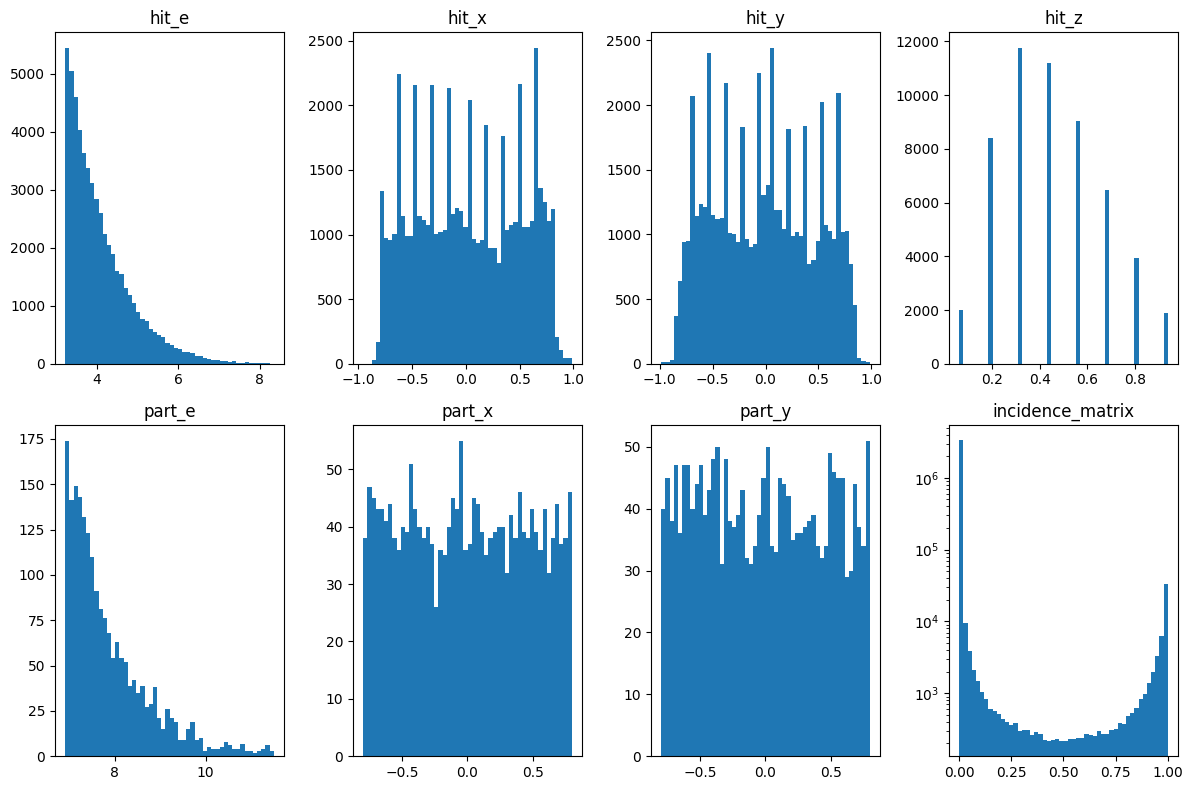

In [32]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 4)
for i, feat in enumerate(inputs):
    ax = fig.add_subplot(gs[0, i])
    x = inputs[feat]
    ax.hist(x, bins=50)
    ax.set_title(feat)
for i, feat in enumerate(targets):
    ax = fig.add_subplot(gs[1, i])
    x = targets[feat]
    ax.hist(x, bins=50)
    ax.set_title(feat)
    if feat == 'incidence_matrix':
        ax.set_yscale('log')
plt.tight_layout()
plt.show()

